# Evaluate Bayesian Linear Regression in terms of Generalization Loss
+ Here, we consider about a regression problem: $y = w^T x$, $w, x \in R^M$ and $w$ is a parameter
+ In this case, several quantities that needs to calculate generalization loss $G_n = -E_X[\log p(y|x, x^n,y^n)$ is tractable.
+ Thus, we first put true distribution $q(x,y)$ as $q(x,y)=q(x)q(y|x), q(x)=N(x|0, I_M), q(y|x)=N(y|x^T w_0, 1)$.
+ By using the true distribution, we calculate posterior and predictive distriubtion of Bayesian method.

In [1]:
from itertools import product
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [2]:
n_train = 100
n_test = 100
M = 10

In [3]:
data_seed = 20251031
np.random.seed(data_seed)
true_w = np.random.normal(size=M)

train_X = np.random.normal(size=(n_train, M))
train_Y = train_X @ true_w + np.random.normal(size=n_train)

test_X = np.random.normal(size=(n_test, M))
test_Y = test_X @ true_w + np.random.normal(size=n_test)

# Calculate Posterior Distrubution
+ When a prior distribution $\varphi(w) = N(0, \beta I_M)$, where $\beta$ is a hyperparameter, then the posterior distribution is directly obtained by normal distribution

In [4]:
pri_beta = 0.01

In [5]:
post_beta = train_X.T @ train_X + pri_beta*np.eye(M)

In [6]:
post_mu = np.linalg.solve(post_beta, train_Y @ train_X)

+ the Posterior distribution is characterized by post_mu and post_beta

# Calculate Predictive Distribution
+ Predictive distribution is $p(y|x, x^n, y^n) = N(y|x^T postmu, \sqrt{x^T postbeta^-1 x})$

In [7]:
pred_y = test_X @ post_mu

## Generalization loss and empirical loss
+ empirical loss is calculated by training data, and generalization loss is calculated by test data, substituing them in the predictive distribution

In [8]:
M / (2*n_train)

0.05

In [9]:
empirical_entropy = -norm.logpdf(train_Y, (train_X @ true_w), 1).mean()
empirical_loss = -norm.logpdf(train_Y, train_X @ post_mu, np.sqrt(1+(train_X * np.linalg.solve(post_beta, train_X.T).T).sum(axis=1))).mean()

In [10]:
empirical_loss - empirical_entropy

np.float64(-0.08286877189940633)

In [11]:
-M / (2*n_train)

-0.05

In [12]:
generalization_entropy = -norm.logpdf(test_Y, (test_X @ true_w), 1).mean()
generalization_loss = -norm.logpdf(test_Y, test_X @ post_mu, np.sqrt(1+(train_X * np.linalg.solve(post_beta, train_X.T).T).sum(axis=1))).mean()

In [13]:
generalization_loss - generalization_entropy

np.float64(0.029622058691717523)

In [14]:
generalization_loss

np.float64(1.540507601013704)

In [15]:
ric = empirical_loss + M/n_train

# Check deviation of losses
+ These losses are random variables of samples

In [48]:
@dataclass
class BayesianResults:
    empirical_loss: float
    empirical_entropy: float
    generalization_loss: float
    generalization_entropy: float
    ric: float
    functional_var: float | None = None

In [17]:
def calc_form_of_pred_dist(input_X: np.ndarray, mu: np.ndarray, beta: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    pred_mu = input_X @ mu
    pred_sigma = np.sqrt(1+(input_X * np.linalg.solve(beta, input_X.T).T).sum(axis=1))
    return pred_mu, pred_sigma

In [18]:
n_datasets = 100
n_trains = [10, 50, 100, 500, 1000, 5000, 10000]
n_tests = [10, 50, 100, 500, 1000, 5000, 10000]

In [19]:
pri_beta = 0.01

In [20]:
data_seed = 20251102
np.random.seed(data_seed)
true_w = np.random.normal(size=M)

results_history: dict[tuple[int, int, int], BayesianResults] = dict()
for n_dataset, (n_train, n_test) in product(range(n_datasets), zip(n_trains, n_tests)):   
    # generate data
    train_X = np.random.normal(size=(n_train, M))
    train_Y = train_X @ true_w + np.random.normal(size=n_train)
    test_X = np.random.normal(size=(n_test, M))
    test_Y = test_X @ true_w + np.random.normal(size=n_test)
    
    # calc posterior distribution
    post_beta = train_X.T @ train_X + pri_beta*np.eye(M)
    post_mu = np.linalg.solve(post_beta, train_Y @ train_X)
    
    # calc predictive distribution
    pred_test_y, pred_test_sigma = calc_form_of_pred_dist(test_X, post_mu, post_beta)
    pred_train_y, pred_train_sigma = calc_form_of_pred_dist(train_X, post_mu, post_beta)
    
    # calc losses
    empirical_entropy = -norm.logpdf(train_Y, (train_X @ true_w), 1).mean()
    empirical_loss = -norm.logpdf(train_Y, pred_train_y, pred_train_sigma).mean()
    generalization_entropy = -norm.logpdf(test_Y, (test_X @ true_w), 1).mean()
    generalization_loss = -norm.logpdf(test_Y, pred_test_y, pred_test_sigma).mean()
    ric = empirical_loss + M/n_train
    
    results_history[(n_dataset, n_train, n_test)] = BayesianResults(
        empirical_loss=empirical_loss,
        empirical_entropy=empirical_entropy,
        generalization_loss=generalization_loss,
        generalization_entropy=generalization_entropy,
        ric=ric,
    )
    pass

In [21]:
results_for_plt = np.array([
    (
        items[1],
        results.empirical_loss,
        results.empirical_loss - results.empirical_entropy,
        results.generalization_loss,
        results.generalization_loss - results.generalization_entropy,
        results.ric,
    )
    for items, results in results_history.items()
])

## Compare losses

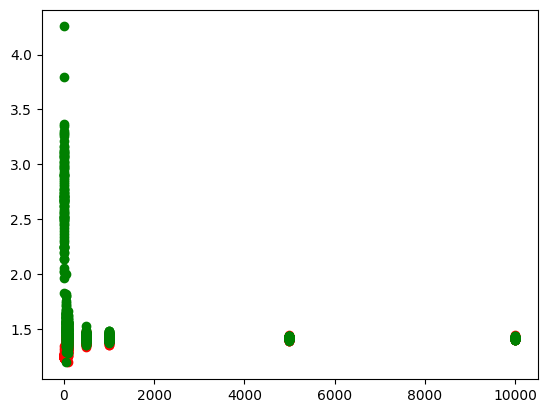

In [22]:
# empirical loss
plt.scatter(results_for_plt[:,0], results_for_plt[:,1], c="r")

# generalization loss
plt.scatter(results_for_plt[:,0], results_for_plt[:,3], c="g")

## Compare errors
+ Since p(x|w) is realizable for true distribution, two errors are $\frac{d}{2n}, -\frac{d}{2n}$ respectively.

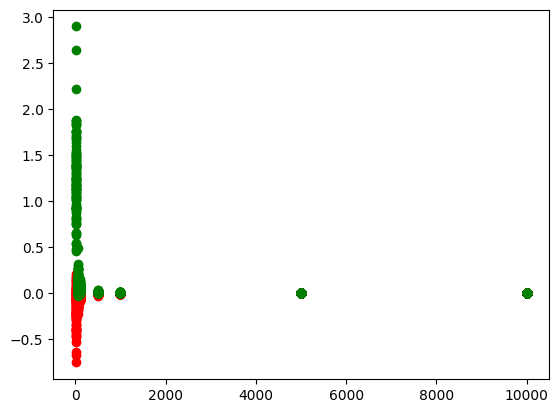

In [23]:
# empirical error
plt.scatter(results_for_plt[:,0], results_for_plt[:,2], c="r")

# generalization error
plt.scatter(results_for_plt[:,0], results_for_plt[:,4], c="g")

## Compare generalization loss and RIC
+ Generalization loss is close to RIC when n increases

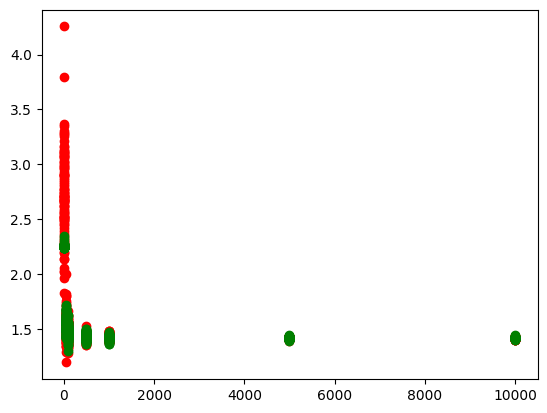

In [24]:
# generalization loss
plt.scatter(results_for_plt[:,0], results_for_plt[:,3], c="r")

# information criterion
plt.scatter(results_for_plt[:,0], results_for_plt[:,5], c="g")

# Not realizable case
+ As a simple case, we focus on $p(y|x,w) = N(y|x^T w, \sigma^2), q(y|x) = N(y|x^T w_0, \sigma_0^2)$.
+ Intuitively, When $\sigma_0$ is small, confidence of empirical error is close to generalization error.
+ This intuition is correct because difference betwee empirical and generalization is $tr(IJ^{-1}) = \frac{\sigma_0^2}{\sigma^2} \times d$

In [49]:
def calc_form_of_pred_dist(input_X: np.ndarray, mu: np.ndarray, beta: np.ndarray, pri_sigma: float = 1) -> tuple[np.ndarray, np.ndarray]:
    pred_mu = input_X @ mu
    pred_sigma = pri_sigma * np.sqrt(1+(input_X * np.linalg.solve(beta, input_X.T).T).sum(axis=1))
    return pred_mu, pred_sigma

In [50]:
def calc_functional_variance(input_X: np.ndarray, output_Y: np.ndarray, mu: np.ndarray, beta: np.ndarray) -> float:
    mean_regression = input_X @ mu
    var_regression = (input_X * np.linalg.solve(beta, input_X.T).T).sum(axis=1)
    
    moment_y1 = mean_regression
    moment_y2 = mean_regression**2 + var_regression
    moment_y3 = mean_regression**3 + 3*mean_regression*var_regression
    moment_y4 = mean_regression**4 + 6*mean_regression**2*var_regression + 3*var_regression**2
    
    func_var = (
        (moment_y4 - 4*output_Y*moment_y3 + 6*output_Y**2*moment_y2 - 4*output_Y**3*moment_y1 + output_Y**4) 
        - (moment_y2 - 2*output_Y*moment_y1 + output_Y**2)**2
    )/4

    return func_var.mean()

In [51]:
n_datasets = 100
n_trains = [5, 10, 50, 100, 500, 1000, 5000, 7500, 10000]
n_tests = [5, 10, 50, 100, 500, 1000, 5000, 7500, 10000]

+ $\sigma_0$ is true_sigma, $\sigma$ is train_sigma
+ When true_sigma is larger than train_sigma, higher correction is needed to estimate generalization loss from empirical loss.
+ Conversely, when true_sigma is smaller than train_sigma, lower correction is needed.

In [52]:
pri_beta = 0.01
train_sigma = np.sqrt(1)
true_sigma = np.sqrt(4)

In [53]:
data_seed = 20251102
np.random.seed(data_seed)
true_w = np.random.normal(size=M)

results_history: dict[tuple[int, int, int], BayesianResults] = dict()
for n_dataset, (n_train, n_test) in product(range(n_datasets), zip(n_trains, n_tests)):   
    # generate data
    train_X = np.random.normal(size=(n_train, M))
    train_Y = train_X @ true_w + np.random.normal(size=n_train, scale=true_sigma)
    test_X = np.random.normal(size=(n_test, M))
    test_Y = test_X @ true_w + np.random.normal(size=n_test, scale=true_sigma)
    
    # calc posterior distribution
    post_beta = train_X.T @ train_X + pri_beta*np.eye(M)
    post_mu = np.linalg.solve(post_beta, train_Y @ train_X)
    
    # calc predictive distribution
    pred_test_y, pred_test_sigma = calc_form_of_pred_dist(test_X, post_mu, post_beta, pri_sigma=train_sigma)
    pred_train_y, pred_train_sigma = calc_form_of_pred_dist(train_X, post_mu, post_beta, pri_sigma=train_sigma)
    
    # calc losses
    empirical_entropy = -norm.logpdf(train_Y, (train_X @ true_w), true_sigma).mean()
    empirical_loss = -norm.logpdf(train_Y, pred_train_y, pred_train_sigma).mean()
    generalization_entropy = -norm.logpdf(test_Y, (test_X @ true_w), true_sigma).mean()
    generalization_loss = -norm.logpdf(test_Y, pred_test_y, pred_test_sigma).mean()
    ric = empirical_loss + (true_sigma**2/train_sigma**2)*M/n_train
    functional_variance = calc_functional_variance(train_X, train_Y, post_mu, post_beta)
    
    results_history[(n_dataset, n_train, n_test)] = BayesianResults(
        empirical_loss=empirical_loss,
        empirical_entropy=empirical_entropy,
        generalization_loss=generalization_loss,
        generalization_entropy=generalization_entropy,
        ric=ric,
        functional_var=functional_variance,
    )
    pass

In [56]:
results_for_plt = np.array([
    (
        items[1],
        results.empirical_loss,
        results.empirical_loss - results.empirical_entropy,
        results.generalization_loss,
        results.generalization_loss - results.generalization_entropy,
        results.ric,
        results.functional_var,
    )
    for items, results in results_history.items()
])

## Compare losses

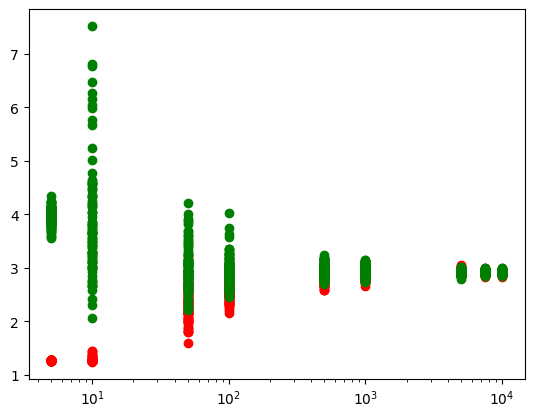

In [30]:
plt.xscale("log")

# empirical loss
plt.scatter(results_for_plt[:,0], results_for_plt[:,1], c="r")

# generalization loss
plt.scatter(results_for_plt[:,0], results_for_plt[:,3], c="g")

## Compare errors

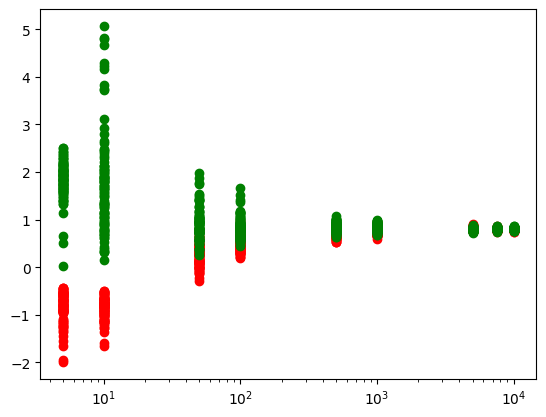

In [31]:
plt.xscale("log")

# empirical error
plt.scatter(results_for_plt[:,0], results_for_plt[:,2], c="r")

# generalization error
plt.scatter(results_for_plt[:,0], results_for_plt[:,4], c="g")

## Compare generalization loss and RIC
+ Generalization loss is close to RIC when n increases

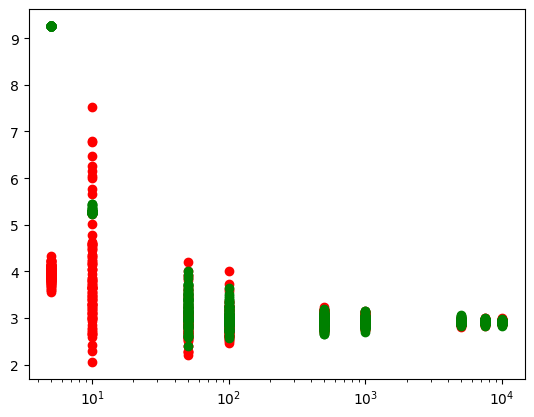

In [32]:
plt.xscale("log")
# generalization loss
plt.scatter(results_for_plt[:,0], results_for_plt[:,3], c="r", )

# information criterion
plt.scatter(results_for_plt[:,0], results_for_plt[:,5], c="g")

## Compare functional variance
+ While $tr(IJ^{-1})$ needs optimal parameter,
+ functional variance $\frac{1}{n} \sum_{i=1}^n var_w[\log p(y_i|x_i, w)]$ not need to information of true distribution.
+ Therefore, we also check whether the functional variance can approximate $tr(IJ^{-1})$

In [60]:
tr_ij = (true_sigma**2/train_sigma**2)*M/results_for_plt[:,0]

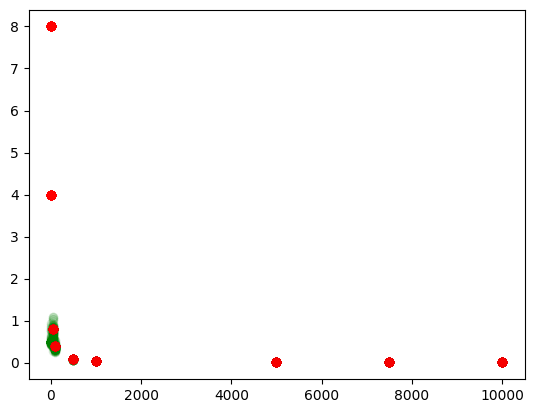

In [66]:
# functional variance
plt.scatter(results_for_plt[:,0], results_for_plt[:,6], c="g", alpha=0.1)

# tr_ij
plt.scatter(results_for_plt[:,0], tr_ij, c="r", alpha=0.1)